In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df= pd.read_csv("Customer Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#since the Dtype of TotalCharges column is Object due to blank space
#we have to convert back to float

df['TotalCharges']=df['TotalCharges'].replace(' ',"0")
df['TotalCharges']=df['TotalCharges'].astype(float)

In [6]:
#to check whether the column has successfully converted or not
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [9]:
df['customerID'].duplicated().sum()

np.int64(0)

In [10]:
#changing the annotation from 0/1 to yes/no for better understanding
def convert(value):
  if value==0:
    return 'No'
  else:
    return 'Yes'
df['SeniorCitizen']=df['SeniorCitizen'].apply(convert)

In [11]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


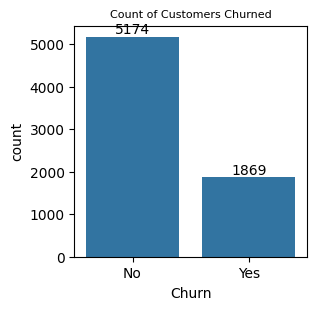

In [12]:
plt.figure(figsize=(3,3))
ax=sns.countplot(x=df['Churn'])
ax.bar_label(ax.containers[0])
plt.title("Count of Customers Churned", fontsize=8)
plt.show()

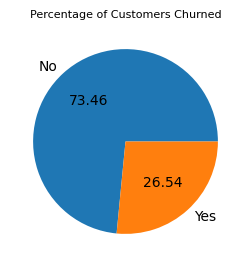

In [13]:
plt.figure(figsize=(3,3))
gb= df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'],labels=gb.index, autopct='%1.2f')
plt.title("Percentage of Customers Churned", fontsize=8)
plt.show()

**From the data we can conclude more than 1/4 th of the customers have been churned out**

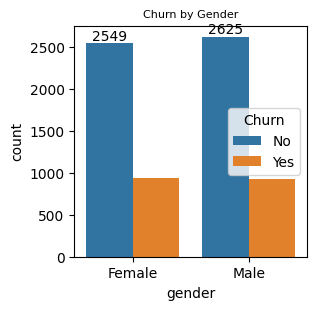

In [14]:
plt.figure(figsize=(3,3))
ax=sns.countplot(x=df['gender'], hue=df['Churn'])
ax.bar_label(ax.containers[0])
plt.title("Churn by Gender", fontsize=8)
plt.show()


**Irrespective of the gender, churn rate is almost the same for both male and female**

Text(0.5, 1.0, 'Churn by SeniorCitizen')

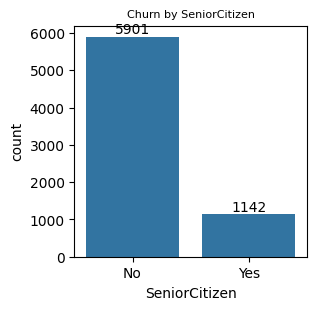

In [15]:
plt.figure(figsize=(3,3))
ax=sns.countplot(x=df['SeniorCitizen'])
ax.bar_label(ax.containers[0])
plt.title("Churn by SeniorCitizen", fontsize=8)

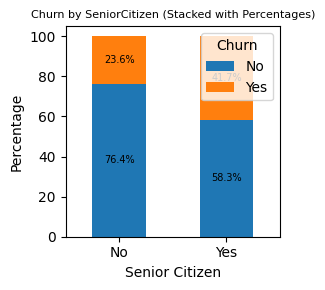

In [16]:
# Calculate churn counts
churn_counts = df.groupby(['SeniorCitizen', 'Churn']).size().unstack(fill_value=0)

# Calculate total counts by SeniorCitizen
total_counts = df.groupby('SeniorCitizen').size()

# Calculate percentages
churn_percentage = churn_counts.div(total_counts, axis=0) * 100

# Create a stacked bar plot
fig, ax = plt.subplots(figsize=(3, 3))
churn_percentage.plot(kind='bar', stacked=True, ax=ax)

# Add percentages to the plot
for container in ax.containers:
    for i, patch in enumerate(container.patches):
        percentage = patch.get_height()
        if percentage > 0:  # Only label if there is a bar
            ax.text(patch.get_x() + patch.get_width() / 2,
                    patch.get_y() + patch.get_height() / 2,
                    f'{percentage:.1f}%',
                    ha='center', va='center', color='black', fontsize=7)

# Set title and labels
ax.set_title("Churn by SeniorCitizen (Stacked with Percentages)", fontsize=8)
ax.set_xlabel("Senior Citizen")
ax.set_ylabel("Percentage")
ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Yes'], rotation=0) # Assuming 0 for No, 1 for Yes
plt.legend(title='Churn')
plt.tight_layout()

**From the above stacked plot a large percentage of senior customers have been churning out**

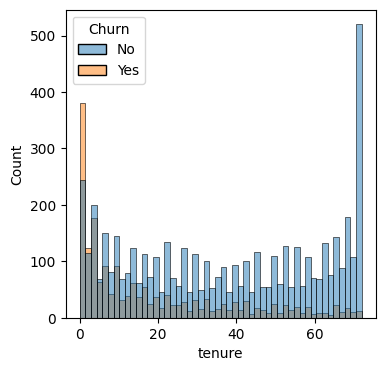

In [22]:
plt.figure(figsize=(4,4))
sns.histplot(x=df['tenure'],hue=df['Churn'],bins=50)
plt.show()

***People who *have* used the services have stayed for a long time, while customers are being churned during the initial periods.***

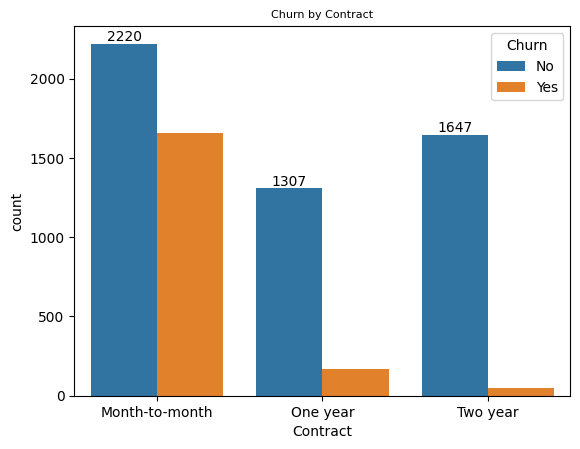

In [27]:
ax=sns.countplot(x=df['Contract'],hue=df['Churn'])
ax.bar_label(ax.containers[0])
plt.title("Churn by Contract", fontsize=8)
plt.show()

**Customers who have shorter contract period have a high probability of churning out.**

In [28]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

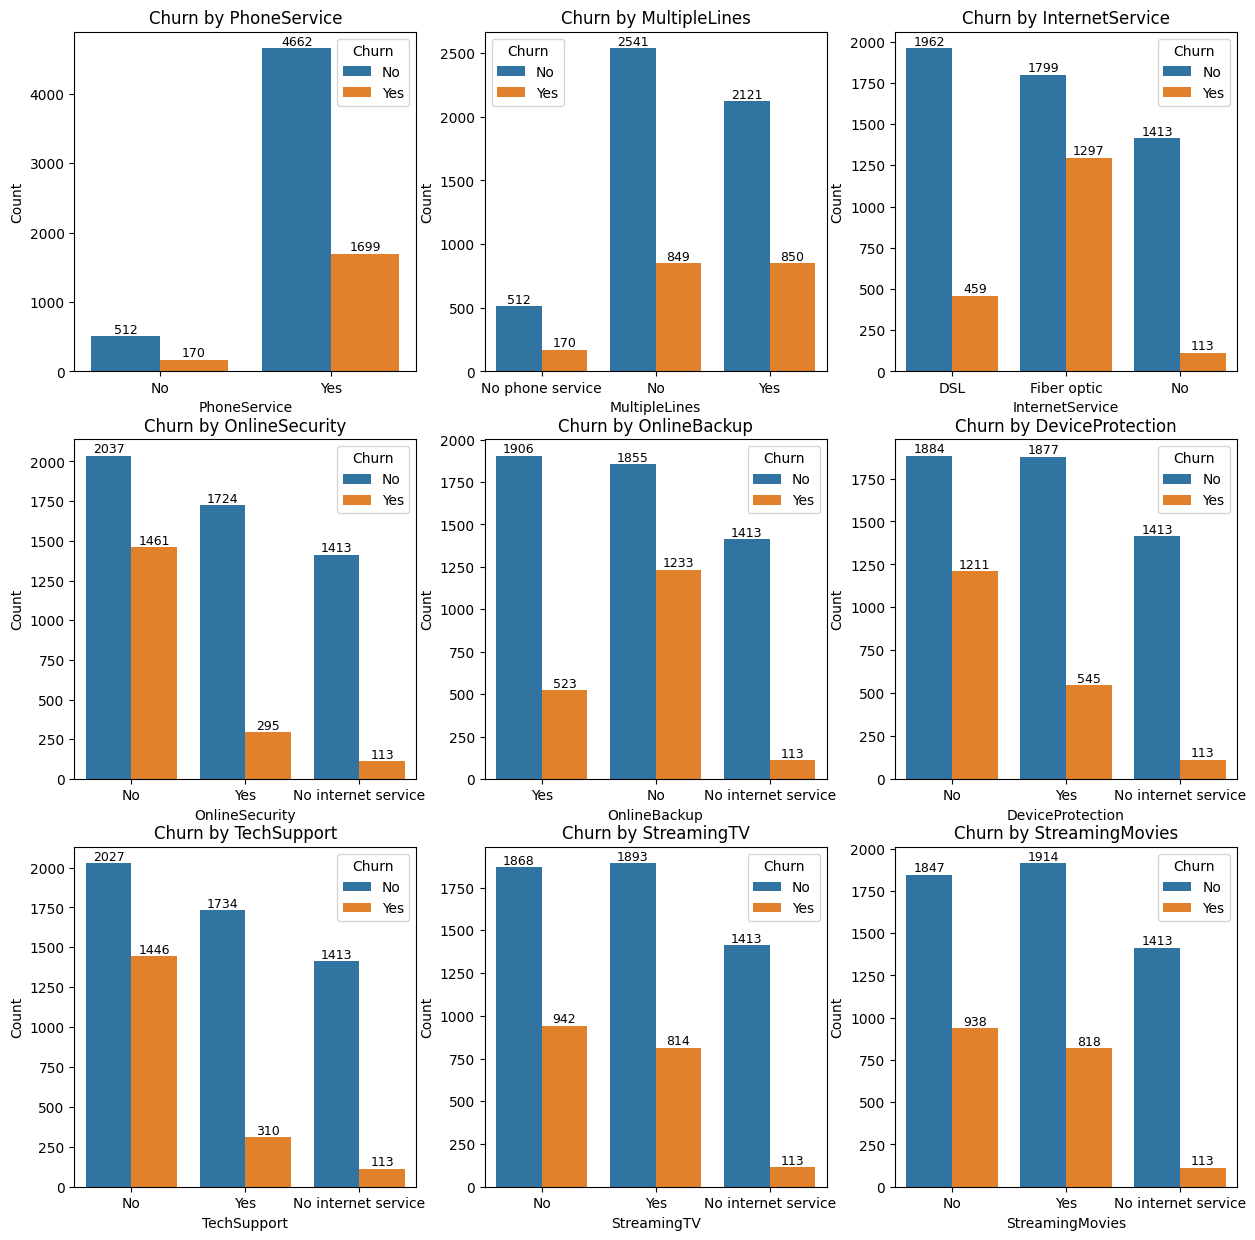

In [30]:
columns_to_plot = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies'
]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    sns.countplot(x=df[col], hue=df['Churn'], ax=ax)
    ax.set_title(f'Churn by {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    # Add bar labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=9)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

**REPORT**

Fiber Optic internet service is a major churn driver, with significantly higher churn rates. Conversely, customers without phone service or those with "No internet service" churn less frequently. Essential services like online security, backup, device protection, tech support, and streaming all correlate with lower churn when utilized, suggesting they are vital for customer retention.

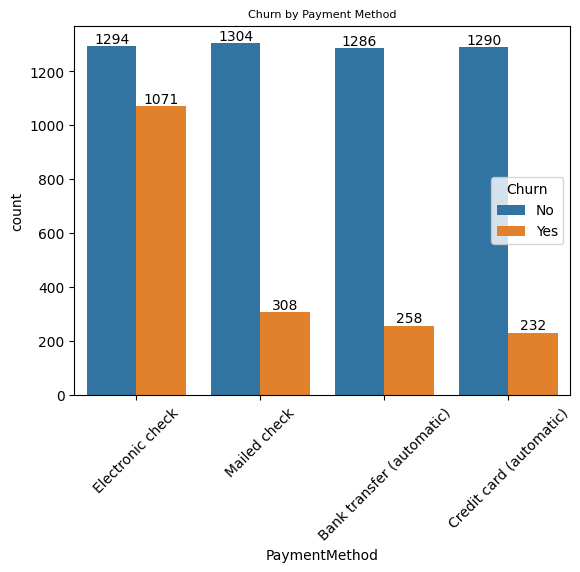

In [34]:
ax=sns.countplot(x=df['PaymentMethod'],hue=df['Churn'])
plt.title("Churn by Payment Method", fontsize=8)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xticks(rotation=45)
plt.show()

The customers who are paying by Electronic check are likely to churn compared to other modes of payments.